# EDA - Main datasets

## Libraries

In [14]:
#Call libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import csv
import seaborn as sns

## Functions

In [3]:
#Identify outliers using the IQR method
def identify_outliers(df):
    ''' A function that identifies outliers in a dataframe using the IQR method. 
    It returns a dictionary with the column names as keys and the number of outliers as values. '''
    outliers_dict = {}
    for column in df.columns:
        if df[column].dtype in ['int64', 'float64']:
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
            outliers_dict[column] = outliers.shape[0]
    return outliers_dict

In [4]:
#Identify null values in the dataframe
def identify_null_values(df):
    ''' A function that identifies columns with null values in a dataframe. 
    It returns a list with the column names that have null values. '''
    null_values_list = []
    for column in df.columns:
        if df[column].isnull().sum() > 0:
            null_values_list.append(column)
    return null_values_list

## Dataset

In [5]:
#StudentPerformanceFactors dataset - Dataset1
student_performance_factors = pd.read_csv('Dataset/Dataset1_StudentPerformanceFactors.csv')
display(student_performance_factors.head(5))
print(student_performance_factors.info())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [6]:
#student_data dataset - Dataset2
#student_data = pd.read_csv('Dataset/Dataset2_student_data.csv')
#display(student_data.head(5))
#print(student_data.info())
#We don't use this dataset because it is not related to the project. It is just a sample dataset for testing purposes.

## Numeric colunms treatment

### Describing numeric columns

In [7]:
#Identify the columns with numeric values and apply the describe() method to get a summary of the statistics for those columns
display(student_performance_factors.describe())

#Apply IQR method in the numeric columns to identify outliers
outliers_dict = identify_outliers(student_performance_factors)
for column, count in outliers_dict.items():
    print(f'Number of outliers in {column}: {count}')

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Number of outliers in Hours_Studied: 43
Number of outliers in Attendance: 0
Number of outliers in Sleep_Hours: 0
Number of outliers in Previous_Scores: 0
Number of outliers in Tutoring_Sessions: 430
Number of outliers in Physical_Activity: 0
Number of outliers in Exam_Score: 104


### Exam_Score first treatment

In [8]:
#Colunm Exam_Score - Count values that are less than 0 and greater than 100
outliers_exam_score = student_performance_factors[(student_performance_factors['Exam_Score'] < 0) 
                                                  | (student_performance_factors['Exam_Score'] > 100)]
print(f'Number of outliers in Exam_Score: {outliers_exam_score.shape[0]}')

#Remove outliers in Exam_Score column that are less than 0 and greater than 100
student_performance_factors = student_performance_factors[(student_performance_factors['Exam_Score'] >= 0) 
                                                          & (student_performance_factors['Exam_Score'] <= 100)]

Number of outliers in Exam_Score: 1


### Understanding the correlation between Numeric columns and Tutoring_Sessions column

In [9]:
#Hypothesis
#First it is interesting to analyze data on children participating in academic support sessions who show the greater outlier values (column Tutoring_Sessions).
Q1 = student_performance_factors['Tutoring_Sessions'].quantile(0.25)
Q3 = student_performance_factors['Tutoring_Sessions'].quantile(0.75)
IQR = Q3 - Q1
student_performance_factors['Outliers_Tutoring_Sessions'] = ["True" if (x < (Q1 - 1.5 * IQR)) 
                                                             | (x > (Q3 + 1.5 * IQR)) else "False" 
                                                             for x in student_performance_factors["Tutoring_Sessions"]]
#Explore Tutoring_sessions outliers
display(
    (
        student_performance_factors[
            student_performance_factors["Outliers_Tutoring_Sessions"] == "True"
        ].sort_values(by="Tutoring_Sessions")
    ).describe()
)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000
mean,19.510490,80.212121,6.974359,74.981352,4.379953,3.121212,68.526807
std,5.951754,11.639814,1.447458,14.891182,0.668146,1.008952,3.720033
min,4.000000,60.000000,4.000000,50.000000,4.000000,0.000000,59.000000
25%,16.000000,71.000000,6.000000,62.000000,4.000000,2.000000,66.000000
50%,19.000000,80.000000,7.000000,74.000000,4.000000,3.000000,68.000000
75%,23.000000,90.000000,8.000000,89.000000,5.000000,4.000000,71.000000
max,35.000000,100.000000,10.000000,100.000000,8.000000,6.000000,99.000000


In [ ]:
#Apply the OLS (Ordinary Least Squares) regression method
#X is the independent variable (cause) and Y is the dependent variable (effect).
X = student_performance_factors[
    [
        "Hours_Studied",
        "Attendance",
        "Sleep_Hours",
        "Previous_Scores",
        "Tutoring_Sessions",
        "Physical_Activity"
    ]
]
Y = student_performance_factors["Exam_Score"]

#Add the constant
X = sm.add_constant(X)

#Model training with Ordinary Least Squares
Tutoring_Sessions_Model = sm.OLS(Y, X).fit()

#Results
print(Tutoring_Sessions_Model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     1651.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:22:24   Log-Likelihood:                -15282.
No. Observations:                6606   AIC:                         3.058e+04
Df Residuals:                    6599   BIC:                         3.062e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                41.0081      0.33

In [ ]:
#My notes:
#The six variables analyzed explain approximately 60% of the variation in student performance (Exam_Score).
#Hours_Studied, Attendance, Previous_Scores, Tutoring_Sessions, and Physical_Activity show positive and statistically significant relationships with the score. 
#Sleep_Hours, on the other hand, was not statistically significant in the model.
#The model as a whole is statistically significant and shows no evidence of residual autocorrelation.

## String colunms treatment

In [11]:
#Colunms treatment - Identification of columns with null values
null_columns = identify_null_values(student_performance_factors)
for column in null_columns:
    print(f'\nColumn {column} has {student_performance_factors[column].isnull().sum()} null values.')
    print(f'Percentage of null values in column {column}: {round(student_performance_factors[column].isnull().sum() 
                                                           / student_performance_factors.shape[0] * 100, 2)}%')

#Palliative action -> Continuing the EDA process, we will analyze the distribution of the 'Teacher_Quality', 'Parental_Education_Level', 
#and 'Distance_from_Home' columns to understand their impact on student performance with the null values 
#because they may influence the overall performance of students.


Column Teacher_Quality has 78 null values.
Percentage of null values in column Teacher_Quality: 1.18%

Column Parental_Education_Level has 90 null values.
Percentage of null values in column Parental_Education_Level: 1.36%

Column Distance_from_Home has 67 null values.
Percentage of null values in column Distance_from_Home: 1.01%


## Graphical views

In [12]:
#Reset index
student_performance_factors.reset_index
display(student_performance_factors)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Outliers_Tutoring_Sessions
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,False
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,False
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,False
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,False
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,False
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,False
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,False
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,False


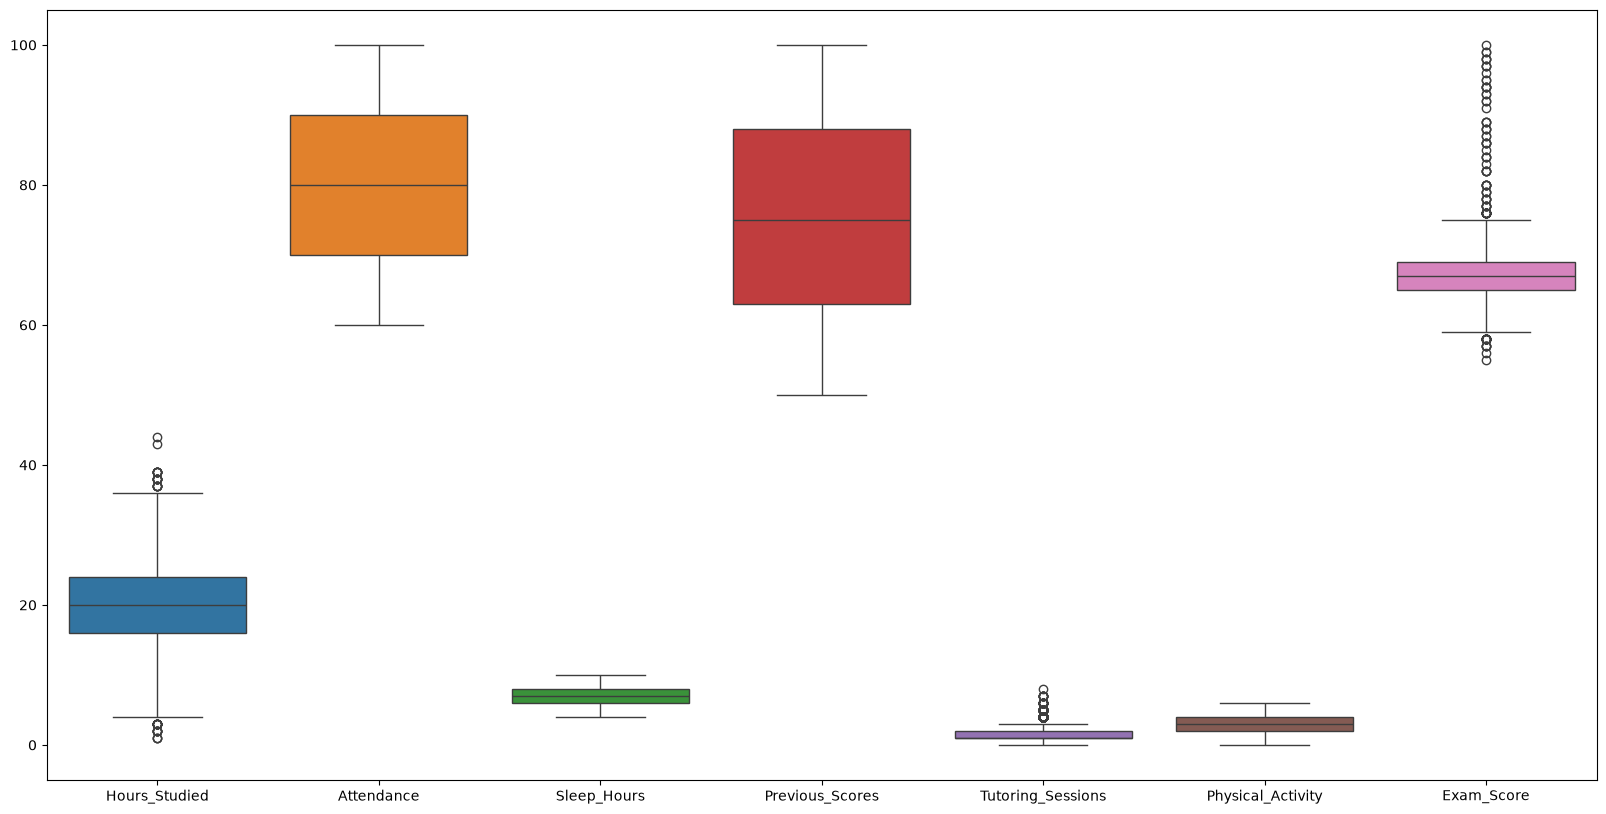

In [ ]:
#We will also visualize these distributions using histograms and boxplots to identify any potential outliers or patterns in the data.
plt.figure(figsize=(20, 10)) 
sns.boxplot(data=student_performance_factors)
plt.show()

## Final Dataset

In [21]:
#CSV convertion
student_performance_factors.to_csv('Dataset/student_performance_factors_for_model.csv', index=False)